<a href="https://colab.research.google.com/github/wvb20/cv-face-alignment/blob/main/notebooks/02_baseline_sift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === Bootstrap — local or Colab ===
import os, subprocess, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_PATH = '/content/cv-face-alignment'
    if not os.path.exists(REPO_PATH):
        subprocess.run(
            ['git', 'clone', 'https://github.com/wvb20/cv-face-alignment.git', REPO_PATH],
            check=True,
        )
    else:
        subprocess.run(['git', '-C', REPO_PATH, 'pull'], check=True)
else:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'config.py').exists():
            REPO_PATH = str(candidate)
            break
    else:
        raise RuntimeError(
            'Could not find the repo root. Start Jupyter from the repository or set CV_FACE_ALIGNMENT_REPO_ROOT.'
        )

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

from src.runtime import configure_notebook_runtime
runtime = configure_notebook_runtime(REPO_PATH)
from src import config, data, evaluate, features, models, visualise, io

print('✓ Setup complete')
runtime_label = 'Colab' if runtime.in_colab else 'Local'
print(f'Runtime:   {runtime_label}')
print(f'Repo:      {runtime.repo_root}')
print(f'Workspace: {runtime.workspace_dir}')

✓ Setup complete
Runtime:   Local
Repo:      /Users/willvaughn/Developer/cv-face-alignment
Workspace: /Users/willvaughn/Developer/cv-face-alignment


In [2]:
# === Load data and apply train/val split ===
images, points = data.load_train()
train_idx, val_idx = data.get_split()

X_train, y_train = images[train_idx], points[train_idx]
X_val,   y_val   = images[val_idx],   points[val_idx]

print(f'Train: {X_train.shape[0]} images')
print(f'Val:   {X_val.shape[0]} images')
print(f'Image shape: {X_train.shape[1:]}, Points shape: {y_train.shape[1:]}')

Train: 2390 images
Val:   421 images
Image shape: (256, 256, 3), Points shape: (5, 2)


In [3]:
# === Mean-shape baseline (the floor everything must beat) ===
meanshape = features.mean_shape(y_train)
print(f'Mean shape:\n{meanshape}')

# "Predict" the mean shape for every val image
y_pred_mean = np.tile(meanshape, (len(X_val), 1, 1))

nme_mean = evaluate.nme(y_pred_mean, y_val)
print(f'\nMean-shape baseline NME: '
      f'mean={nme_mean.mean()*100:.2f}%, '
      f'median={np.median(nme_mean)*100:.2f}%')
print(f'Failure rate (>10%): {evaluate.failure_rate(nme_mean)*100:.1f}%')

Mean shape:
[[ 79.92949627 104.29054562]
 [176.15298394 103.10614619]
 [128.73378415 142.48261132]
 [ 98.61312685 177.1249667 ]
 [159.59675885 176.1246442 ]]

Mean-shape baseline NME: mean=12.60%, median=11.29%
Failure rate (>10%): 60.3%


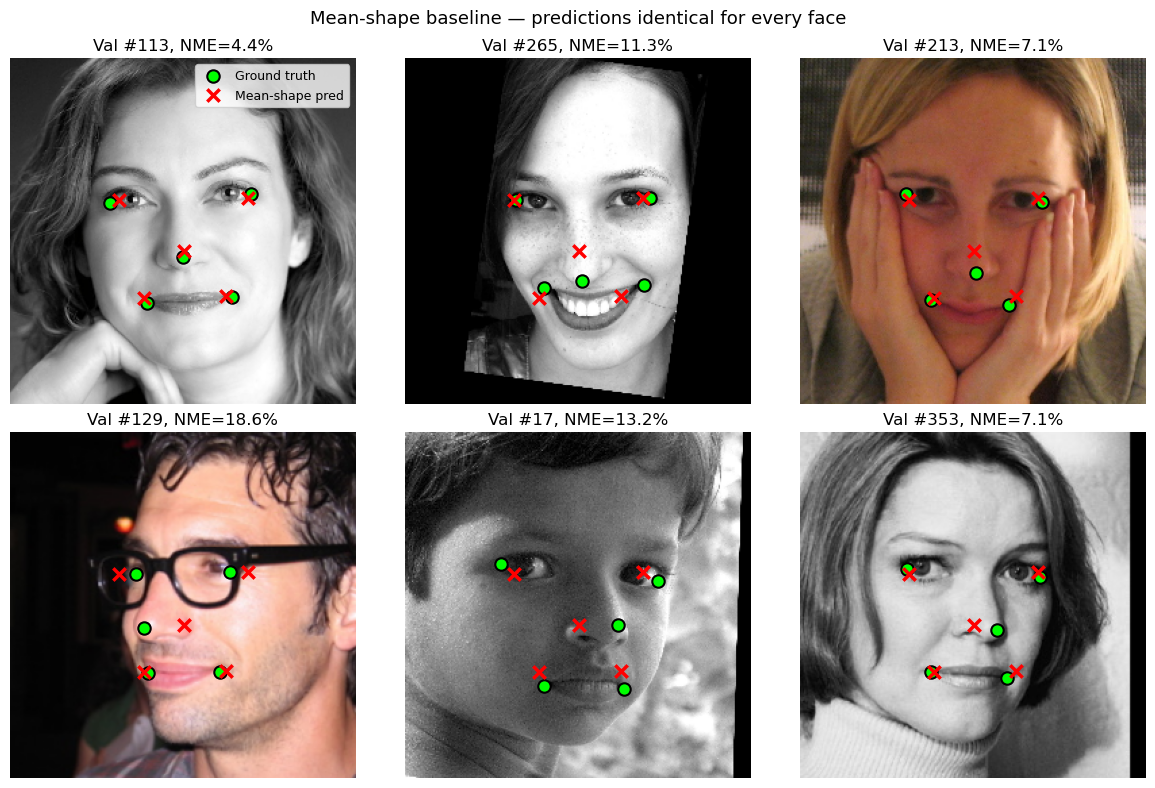

In [4]:
# === Visualise the mean-shape baseline on 6 val examples ===
rng = np.random.default_rng(seed=0)
sample = rng.choice(len(X_val), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, i in zip(axes.flat, sample):
    ax.imshow(X_val[i])
    ax.scatter(y_val[i, :, 0], y_val[i, :, 1],
               s=80, c='lime', edgecolors='black',
               linewidths=1.5, label='Ground truth', zorder=3)
    ax.scatter(y_pred_mean[i, :, 0], y_pred_mean[i, :, 1],
               s=80, marker='x', c='red',
               linewidths=2.5, label='Mean-shape pred', zorder=4)
    ax.set_title(f'Val #{i}, NME={nme_mean[i]*100:.1f}%')
    ax.axis('off')
axes[0, 0].legend(loc='upper right', fontsize=9)
fig.suptitle('Mean-shape baseline — predictions identical for every face',
             fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/04_meanshape_baseline.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [5]:
# === Sanity-check the SIFT feature extraction ===
desc = features.compute_sift_at_points(X_val[0], meanshape)
print(f'SIFT descriptor for one image:')
print(f'  shape: {desc.shape}  (expect (640,) = 5 landmarks × 128 dims)')
print(f'  dtype: {desc.dtype}')
print(f'  range: [{desc.min():.1f}, {desc.max():.1f}]')

SIFT descriptor for one image:
  shape: (640,)  (expect (640,) = 5 landmarks × 128 dims)
  dtype: float32
  range: [0.0, 123.0]


In [6]:
# === Single-stage Ridge regression on SIFT-at-mean-shape ===
from sklearn.linear_model import Ridge
from tqdm import tqdm

def extract_features_batch(images, points_per_image):
    """Extract SIFT features at given points for a batch of images."""
    feats = np.zeros((len(images), config.N_LANDMARKS * 128), dtype=np.float32)
    for i, img in enumerate(tqdm(images, desc='SIFT')):
        feats[i] = features.compute_sift_at_points(img, points_per_image)
    return feats

# Extract SIFT-at-mean-shape features for every train and val image
X_train_feats = extract_features_batch(X_train, meanshape)
X_val_feats   = extract_features_batch(X_val,   meanshape)

# Target: the offset from mean-shape to ground truth (residual learning)
y_train_offset = (y_train - meanshape).reshape(len(y_train), -1)   # (N, 10)
y_val_offset   = (y_val   - meanshape).reshape(len(y_val),   -1)

# Fit Ridge regression
reg = Ridge(alpha=10.0)
reg.fit(X_train_feats, y_train_offset)

# Predict offsets, add mean-shape to get absolute landmark positions
pred_offset = reg.predict(X_val_feats)
y_pred_ridge = pred_offset.reshape(-1, config.N_LANDMARKS, 2) + meanshape

# Score
nme_ridge = evaluate.nme(y_pred_ridge, y_val)
print(f'\nSingle-stage Ridge on SIFT@mean-shape:')
print(f'  NME mean   = {nme_ridge.mean()*100:.2f}%')
print(f'  NME median = {np.median(nme_ridge)*100:.2f}%')
print(f'  Failure rate (>10%) = {evaluate.failure_rate(nme_ridge)*100:.1f}%')

improvement = (nme_mean.mean() - nme_ridge.mean()) * 100
print(f'\nMean-shape baseline was {nme_mean.mean()*100:.2f}% — '
      f'improvement: {improvement:.2f} pp')

SIFT: 100%|██████████| 421/421 [00:00<00:00, 815.77it/s]


Single-stage Ridge on SIFT@mean-shape:
  NME mean   = 4.99%
  NME median = 4.54%
  Failure rate (>10%) = 3.6%

Mean-shape baseline was 12.60% — improvement: 7.62 pp


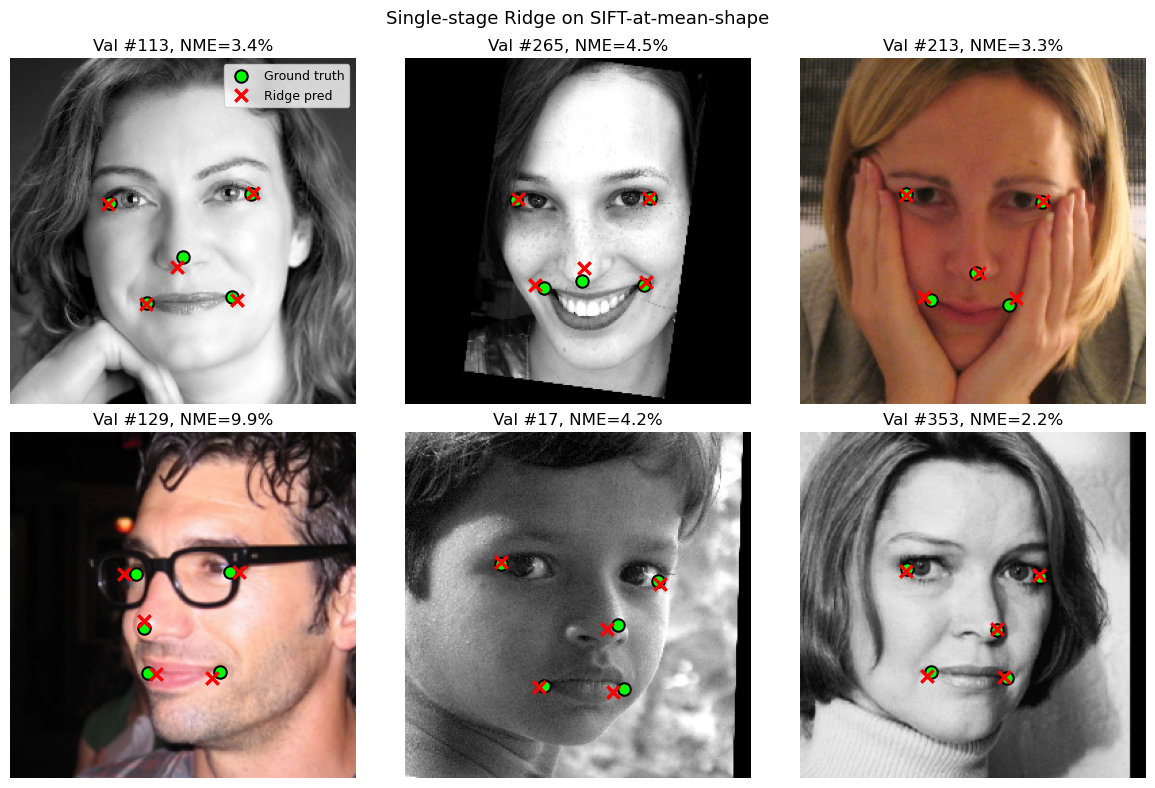

In [7]:
# === Visualise single-stage Ridge predictions on 6 val examples ===
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, i in zip(axes.flat, sample):  # reuse the sample from Cell 4
    ax.imshow(X_val[i])
    ax.scatter(y_val[i, :, 0], y_val[i, :, 1],
               s=80, c='lime', edgecolors='black',
               linewidths=1.5, label='Ground truth', zorder=3)
    ax.scatter(y_pred_ridge[i, :, 0], y_pred_ridge[i, :, 1],
               s=80, marker='x', c='red',
               linewidths=2.5, label='Ridge pred', zorder=4)
    ax.set_title(f'Val #{i}, NME={nme_ridge[i]*100:.1f}%')
    ax.axis('off')
axes[0, 0].legend(loc='upper right', fontsize=9)
fig.suptitle('Single-stage Ridge on SIFT-at-mean-shape', fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/05_ridge_baseline.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# === Train cascaded Ridge regressor ===
# If you changed src/models.py since the kernel started, reload it here.
import importlib
from src import models
importlib.reload(models)

import time

cascade = models.CascadedRidgeRegressor(n_stages=4, alpha=10.0, patch_size=16)

print('Training cascade on training set...')
t0 = time.time()
cascade.fit(X_train, y_train, verbose=True)
print(f'\nTraining time: {time.time() - t0:.1f}s')

Training cascade on training set...
  Stage 1/4: mean per-landmark error = 3.47 px
  Stage 2/4: mean per-landmark error = 2.43 px
  Stage 3/4: mean per-landmark error = 2.34 px
  Stage 4/4: mean per-landmark error = 2.33 px

Training time: 11.7s


In [9]:
# === Evaluate cascade on validation set ===
print('Predicting on validation set...')
y_pred_cascade = cascade.predict(X_val)

nme_cascade = evaluate.nme(y_pred_cascade, y_val)
print(f'\nCascaded Ridge ({cascade.n_stages} stages):')
print(f'  NME mean   = {nme_cascade.mean()*100:.2f}%')
print(f'  NME median = {np.median(nme_cascade)*100:.2f}%')
print(f'  Failure rate (>10%) = {evaluate.failure_rate(nme_cascade)*100:.1f}%')

print(f'\n--- Comparison ---')
print(f'  Mean-shape baseline:  {nme_mean.mean()*100:5.2f}%  '
      f'failures: {evaluate.failure_rate(nme_mean)*100:5.1f}%')
print(f'  Single-stage Ridge:   {nme_ridge.mean()*100:5.2f}%  '
      f'failures: {evaluate.failure_rate(nme_ridge)*100:5.1f}%')
print(f'  Cascaded Ridge ({cascade.n_stages}):  {nme_cascade.mean()*100:5.2f}%  '
      f'failures: {evaluate.failure_rate(nme_cascade)*100:5.1f}%')

Predicting on validation set...

Cascaded Ridge (4 stages):
  NME mean   = 3.86%
  NME median = 3.45%
  Failure rate (>10%) = 0.7%

--- Comparison ---
  Mean-shape baseline:  12.60%  failures:  60.3%
  Single-stage Ridge:    4.99%  failures:   3.6%
  Cascaded Ridge (4):   3.86%  failures:   0.7%


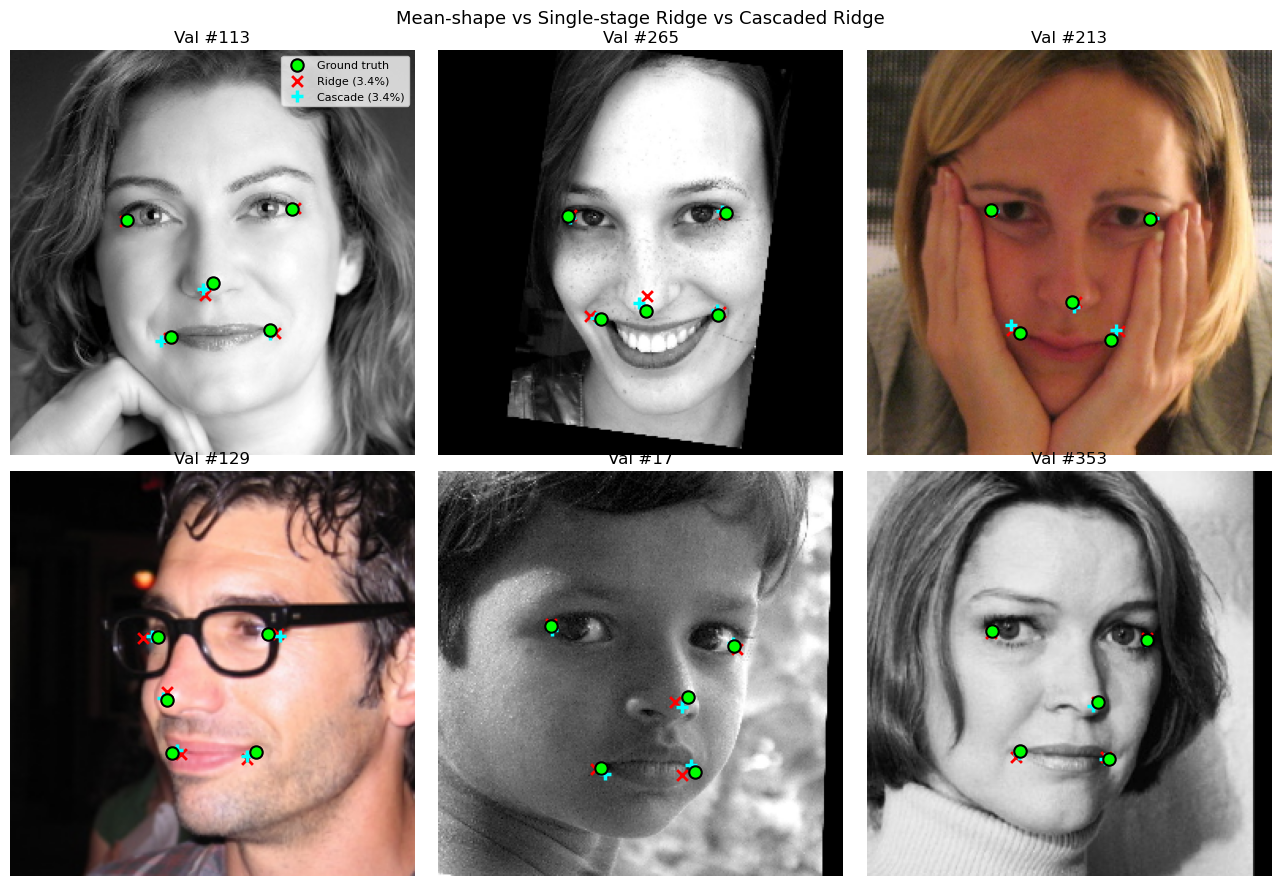

In [10]:
# === Visualise — mean-shape vs single-stage vs cascade ===
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, i in zip(axes.flat, sample):
    ax.imshow(X_val[i])
    ax.scatter(y_val[i, :, 0], y_val[i, :, 1],
               s=80, c='lime', edgecolors='black',
               linewidths=1.5, label='Ground truth', zorder=5)
    ax.scatter(y_pred_ridge[i, :, 0], y_pred_ridge[i, :, 1],
               s=60, marker='x', c='red', linewidths=2,
               label=f'Ridge ({nme_ridge[i]*100:.1f}%)', zorder=4)
    ax.scatter(y_pred_cascade[i, :, 0], y_pred_cascade[i, :, 1],
               s=80, marker='+', c='cyan', linewidths=2.5,
               label=f'Cascade ({nme_cascade[i]*100:.1f}%)', zorder=4)
    ax.set_title(f'Val #{i}')
    ax.axis('off')
axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Mean-shape vs Single-stage Ridge vs Cascaded Ridge', fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/06_cascade_vs_baselines.png',
            dpi=120, bbox_inches='tight')
plt.show()

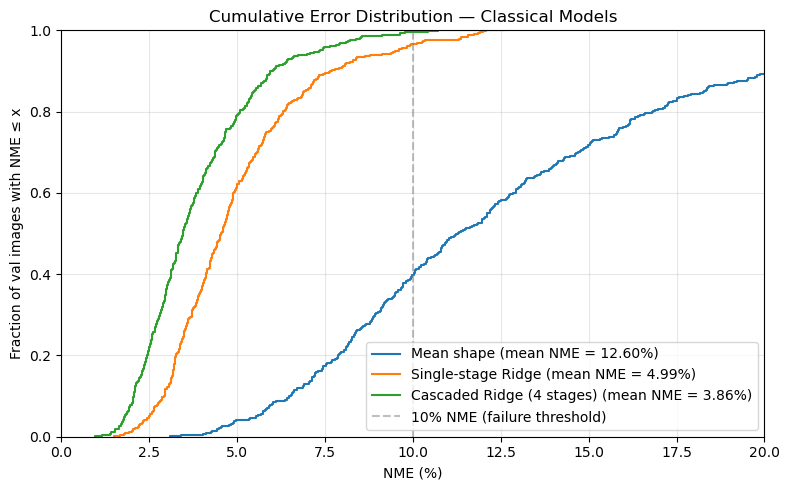

In [11]:
# === Cumulative error distribution — all three classical models ===
fig, ax = plt.subplots(figsize=(8, 5))
for errors, label in [
    (nme_mean,    'Mean shape'),
    (nme_ridge,   'Single-stage Ridge'),
    (nme_cascade, f'Cascaded Ridge ({cascade.n_stages} stages)'),
]:
    x, y = evaluate.cumulative_error_distribution(errors)
    ax.step(x * 100, y, label=f'{label} (mean NME = {errors.mean()*100:.2f}%)')

ax.set_xlabel('NME (%)')
ax.set_ylabel('Fraction of val images with NME ≤ x')
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.0)
ax.axvline(10, ls='--', c='grey', alpha=0.5,
           label='10% NME (failure threshold)')
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
ax.set_title('Cumulative Error Distribution — Classical Models')
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/07_ced_classical.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# === Generate test predictions from the cascade (safety-net) ===
test_images = data.load_test()
print(f'Test set: {test_images.shape}')

print('Predicting on test set...')
y_pred_test = cascade.predict(test_images)
print(f'Predictions shape: {y_pred_test.shape}  (expect (554, 5, 2))')

# Save in the assignment-required format
output_dir = f'{REPO_PATH}/outputs'
os.makedirs(output_dir, exist_ok=True)
io.save_as_csv(y_pred_test, location=output_dir)

# The save_as_csv function writes to results_task2.csv. Rename so we know
# which model produced these (we'll also have a CNN version later).
import shutil
src_csv  = f'{output_dir}/results_task2.csv'
dest_csv = f'{output_dir}/results_task2_cascade.csv'
shutil.copy(src_csv, dest_csv)
print(f'\n✓ Saved cascade predictions to:')
print(f'  {dest_csv}')
print(f'  ({os.path.getsize(dest_csv):,} bytes)')

# Also stash a copy in the workspace root for easy access.
workspace_csv = f'{config.DRIVE_PROJECT_DIR}/results_task2_cascade.csv'
shutil.copy(src_csv, workspace_csv)
print(f'  {workspace_csv}  (workspace copy)')

Test set: (554, 256, 256, 3)
Predicting on test set...
Predictions shape: (554, 5, 2)  (expect (554, 5, 2))

✓ Saved cascade predictions to:
  /Users/willvaughn/Developer/cv-face-alignment/outputs/results_task2_cascade.csv
  (138,500 bytes)
  /Users/willvaughn/Developer/cv-face-alignment/results_task2_cascade.csv  (workspace copy)


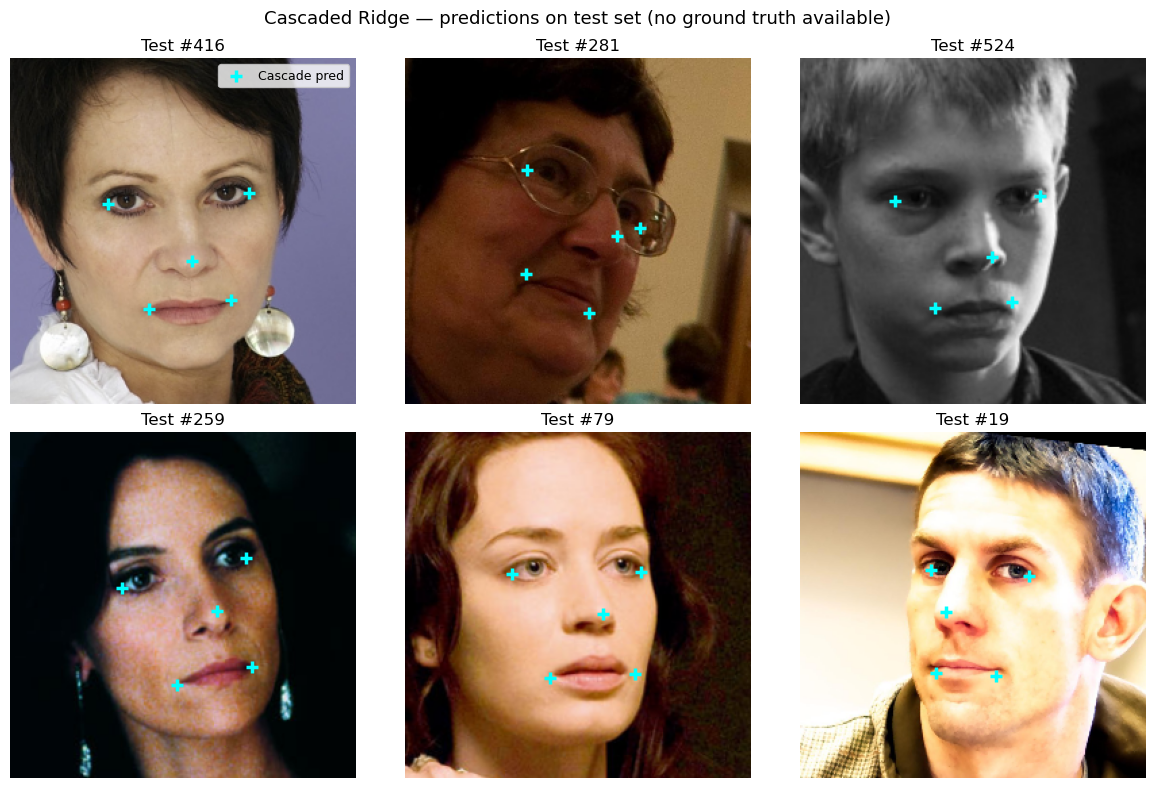

In [13]:
# === Visualise cascade predictions on 6 random test images ===
rng = np.random.default_rng(seed=1)
test_sample = rng.choice(len(test_images), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, i in zip(axes.flat, test_sample):
    ax.imshow(test_images[i])
    ax.scatter(y_pred_test[i, :, 0], y_pred_test[i, :, 1],
               s=80, marker='+', c='cyan',
               linewidths=2.5, label='Cascade pred', zorder=4)
    ax.set_title(f'Test #{i}')
    ax.axis('off')
axes[0, 0].legend(loc='upper right', fontsize=9)
fig.suptitle('Cascaded Ridge — predictions on test set (no ground truth available)',
             fontsize=13)
fig.tight_layout()
plt.savefig(f'{config.FIGURES_DIR}/08_cascade_test_predictions.png',
            dpi=120, bbox_inches='tight')
plt.show()